# Tiny Dreamer Highway — Colab Sanity Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook for a short Colab validation run before any longer training job.

## Runtime flow

1. Mount Google Drive.
2. Clone or pull the latest repository snapshot.
3. Install the package.
4. Run a short 3-cycle sanity job.
5. Confirm checkpoints, logs, and analysis artifacts are written.

In [23]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'
WORKTREE = Path('/content/CSC_580_Final_Project')

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [24]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi

Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [25]:
%%bash
set -e
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

In [26]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)
print('Loaded config from:', CONFIG_PATH)
print('Base cycles:', config.training.cycles)
print('Base batch size:', config.training.batch_size)

Loaded config from: /content/CSC_580_Final_Project/examples/training_run.yaml
Base cycles: 500
Base batch size: 32


In [27]:
RUN_NAME = 'sanity_check_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 100
WARM_START_STEPS = 64
POLICY_STEPS = 8
CHECKPOINT_INTERVAL = 1
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Cycles:', CYCLES)
print('Warm-start steps:', WARM_START_STEPS)
print('Policy steps:', POLICY_STEPS)

Run name: sanity_check_001
Cycles: 100
Warm-start steps: 64
Policy steps: 8


In [28]:
print('Launching sanity run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching sanity run. Per-cycle progress lines will appear below.
[train] starting run | cycles=100 | start_step=1 | warm_start_steps=64 | policy_steps=8 | device=cuda
[train] step=1/100 | warm=64 | policy=8 | replay=72 | world_total=10.3406 | actor=0.5661 | critic=0.5145 | cycle_s=41.3 | elapsed_s=41.3 | checkpoint=checkpoint_00001.pt
[train] step=2/100 | warm=0 | policy=8 | replay=80 | world_total=9.4239 | actor=0.8536 | critic=1.0150 | cycle_s=4.2 | elapsed_s=45.5 | checkpoint=checkpoint_00002.pt
[train] step=3/100 | warm=0 | policy=8 | replay=88 | world_total=9.0123 | actor=1.1613 | critic=1.8563 | cycle_s=4.7 | elapsed_s=50.2 | checkpoint=checkpoint_00003.pt
[train] step=4/100 | warm=0 | policy=8 | replay=96 | world_total=11.7321 | actor=1.4570 | critic=2.7270 | cycle_s=4.1 | elapsed_s=54.3 | checkpoint=checkpoint_00004.pt
[train] step=5/100 | warm=0 | policy=8 | replay=104 | world_total=8.5405 | actor=1.7973 | critic=4.0324 | cycle_s=4.3 | elapsed_s=58.6 | checkpoint=checkpoint_0

In [29]:
summary_path = training_summary.log_dir / 'latest_summary.json'
metrics_csv_path = training_summary.log_dir / 'cycle_metrics.csv'
metrics_jsonl_path = training_summary.log_dir / 'cycle_metrics.jsonl'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))

print('Summary exists:', summary_path.exists())
print('CSV exists:', metrics_csv_path.exists())
print('JSONL exists:', metrics_jsonl_path.exists())
print('Checkpoint exists:', training_summary.latest_checkpoint is not None and training_summary.latest_checkpoint.exists())
summary_payload

Summary exists: True
CSV exists: True
JSONL exists: True
Checkpoint exists: True


{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/checkpoints/checkpoint_00100.pt',
 'latest_metrics': {'behavior/actor_loss': -0.037786674685776234,
  'behavior/critic_loss': 0.7532195746898651,
  'behavior/imagined_reward_mean': 0.08244167640805244,
  'behavior/imagined_value_mean': -0.5912348628044128,
  'policy_added': 8,
  'replay_size': 864,
  'step': 100,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.0,
  'world_model/kl_loss_raw': 0.3738521337509155,
  'world_model/reconstruction_loss': 0.022762179374694824,
  'world_model/reward_loss': 3.3286341428756714,
  'world_model/total_loss': 6.351396560668945},
 'latest_step': 100}

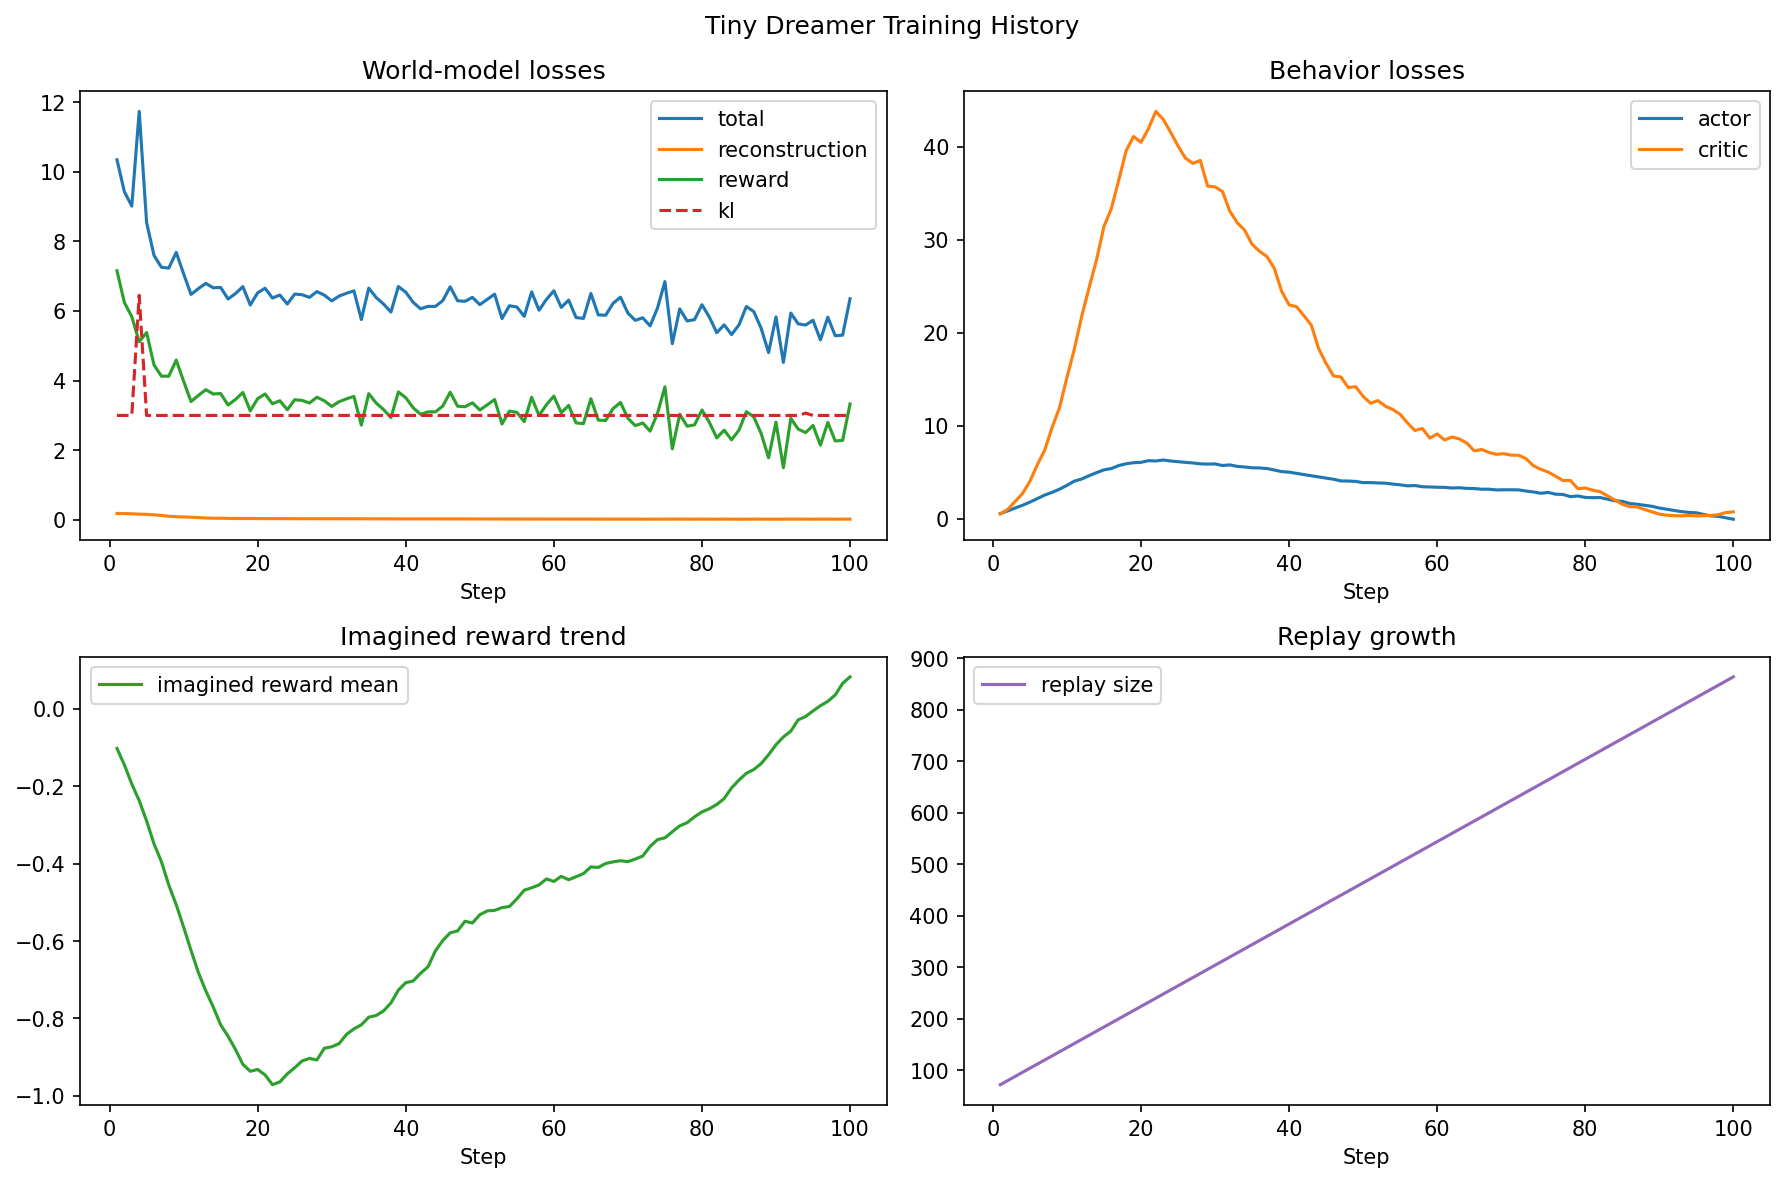

{'summary': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_summary.json'),
 'curves': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_curves.png')}

In [30]:
from IPython.display import Image, display
from tiny_dreamer_highway.evaluation import export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_outputs

## Agent Driving Demo

Record a short GIF showing the trained policy driving in the real highway-env. The checkpoint from the run above is used to load the actor and world model, then the agent is rolled out for a few episodes.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=2 | reward=-2.12 | CRASH | saved sanity_check_001_ep01.gif
[demo] episode 2/10 | steps=3 | reward=-1.24 | CRASH | saved sanity_check_001_ep02.gif
[demo] episode 3/10 | steps=3 | reward=-1.28 | CRASH | saved sanity_check_001_ep03.gif
[demo] episode 4/10 | steps=2 | reward=-2.12 | CRASH | saved sanity_check_001_ep04.gif
[demo] episode 5/10 | steps=5 | reward=0.58 | CRASH | saved sanity_check_001_ep05.gif
[demo] episode 6/10 | steps=3 | reward=-1.24 | CRASH | saved sanity_check_001_ep06.gif
[demo] episode 7/10 | steps=2 | reward=-2.12 | CRASH | saved sanity_check_001_ep07.gif
[demo] episode 8/10 | steps=3 | reward=-1.33 | CRASH | saved sanity_check_001_ep08.gif
[demo] episode 9/10 | steps=2 | reward=-2.12 | CRASH | saved sanity_check_001_ep09.gif
[demo] episode 10/10 | steps=3 | reward=-1.23 | CRASH | saved sanity_check_001_ep10.gif
[demo] done | avg_reward=-1.42 | summary=sanity_check_001

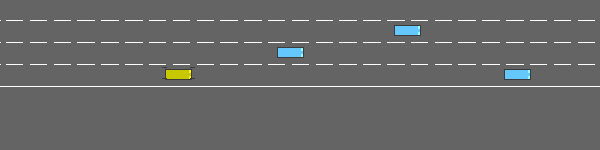


sanity_check_001_ep02.gif


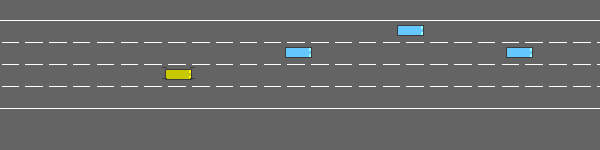


sanity_check_001_ep03.gif


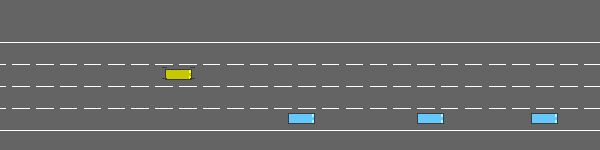


sanity_check_001_ep04.gif


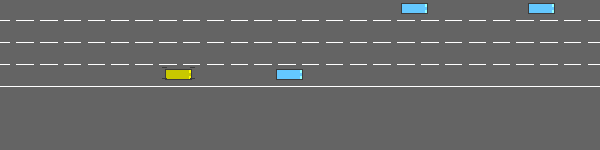


sanity_check_001_ep05.gif


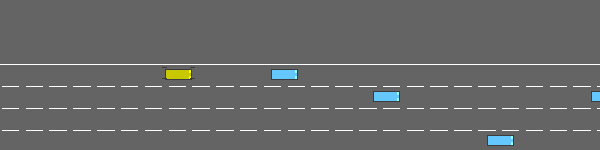


sanity_check_001_ep06.gif


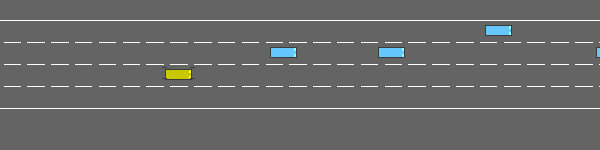


sanity_check_001_ep07.gif


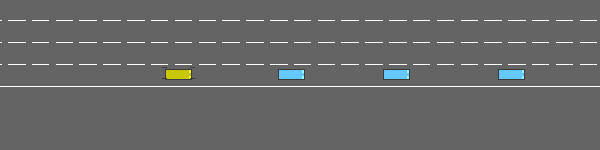


sanity_check_001_ep08.gif


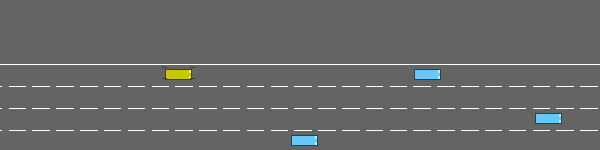


sanity_check_001_ep09.gif


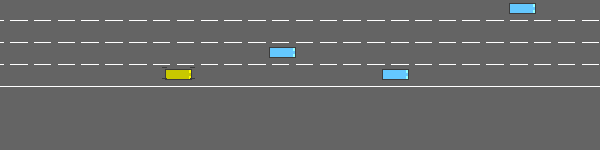


sanity_check_001_ep10.gif


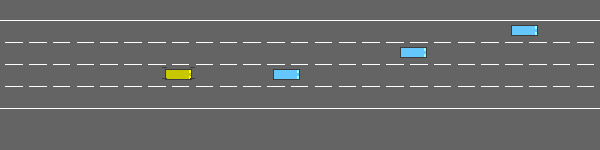

In [32]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=100,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))